In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, load_iris
from sklearn.model_selec



tion import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    roc_curve, auc
)


### 1️⃣ Binary Logistic Regression (Library Implementation)

In [3]:
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_classes=2,
    n_informative=2,
    n_redundant=0,
    random_state=42
)

### 🔹 Train–Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


### 🔹 Feature Scaling

In [5]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

# Why scaling is critical

# Gradient descent converges faster

# Prevents one feature dominating another


### 🔹 Train Logistic Regression

In [6]:
model=LogisticRegression()
model.fit(X_train,y_train)

# What happens internally

# Uses logistic (sigmoid) function

# Optimizes weights using maximum likelihood

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### 2️⃣ Model Evaluation (Binary)

In [7]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

🔹 Metrics

In [8]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.872
Precision: 0.888
Recall: 0.8604651162790697
F1 Score: 0.8740157480314961


### Confusion Matrix

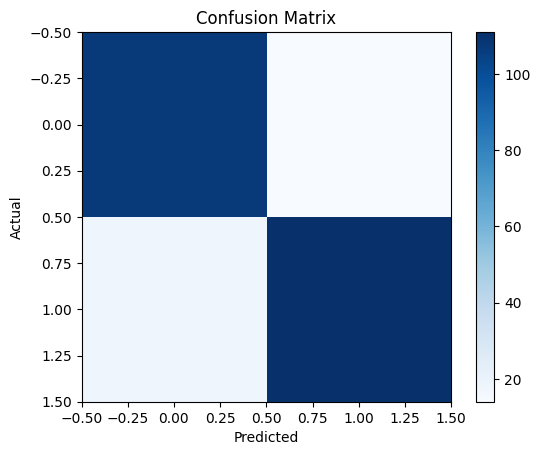

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()


### 3️⃣ ROC Curve & AUC

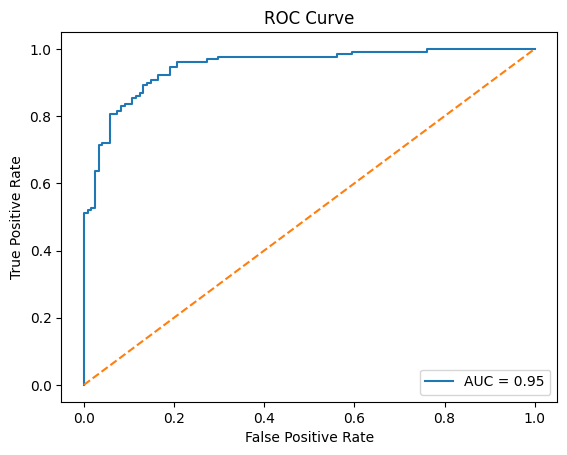

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


### 4️⃣ Binary Logistic Regression from Scratch (Gradient Descent)

In [11]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


### 🔹 Gradient Descent Training

In [12]:
def train_logistic_gd(X, y, lr=0.1, epochs=1000):
    m, n = X.shape
    w = np.zeros(n)
    b = 0
    loss_history = []

    for _ in range(epochs):
        z = np.dot(X, w) + b
        y_hat = sigmoid(z)

        loss = -np.mean(y*np.log(y_hat) + (1-y)*np.log(1-y_hat))
        loss_history.append(loss)

        dw = np.dot(X.T, (y_hat - y)) / m
        db = np.mean(y_hat - y)

        w -= lr * dw
        b -= lr * db

    return w, b, loss_history


### 🔹 Train & Predict

In [13]:
w, b, loss = train_logistic_gd(X_train, y_train)

y_gd_prob = sigmoid(np.dot(X_test, w) + b)
y_gd_pred = (y_gd_prob >= 0.5).astype(int)


### 🔹 Loss Curve

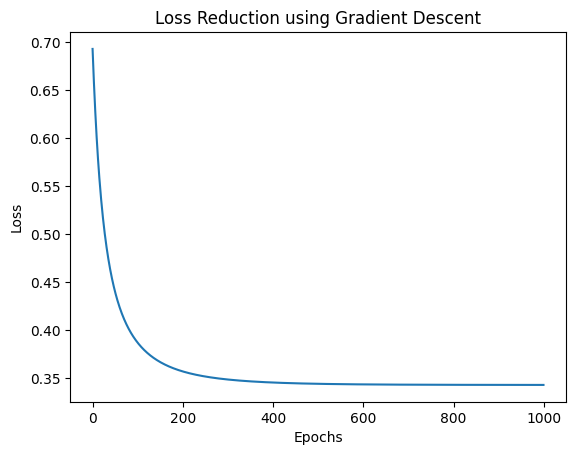

In [14]:
plt.plot(loss)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Reduction using Gradient Descent")
plt.show()


### 5️⃣ Library vs Gradient Descent Comparison

In [15]:
print("Library Accuracy:", accuracy_score(y_test, y_pred))
print("GD Accuracy:", accuracy_score(y_test, y_gd_pred))


Library Accuracy: 0.872
GD Accuracy: 0.872


### 6️⃣ Multinomial Logistic Regression (Multi-Class)

In [16]:
iris = load_iris()
X, y = iris.data, iris.target


### 🔹 Train Model

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Ensure y is 1D
y_train = y_train.ravel()
y_test = y_test.ravel()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Unique y_train:", np.unique(y_train))

model = LogisticRegression(multi_class='multinomial', max_iter=200)
model.fit(X_train, y_train)

X_train shape: (112, 4)
y_train shape: (112,)
Unique y_train: [0 1 2]


TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'